# 09 — Accuracy Comparison

Accuracy of all four trained models on the held-out retest set.

**Prerequisites:** run notebooks 02–05 to populate all model artifacts in `models/`.

## 1. Setup — Load Data & Models

In [4]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import joblib, sys
from pathlib import Path
from sklearn.metrics import accuracy_score

sys.path.insert(0, '../src')
from features import STRUCTURAL_COLS, structural_features, build_features

MODELS_DIR = Path("../models")
NGRAM_N    = 6

lf_rt = pd.read_csv("../data/retest/signed_retest_login_form.csv", index_col=0)
nf_rt = pd.read_csv("../data/retest/signed_retest_no_form.csv",    index_col=0)
for df_ in [lf_rt, nf_rt]:
    for junk in ("Unnamed: 0", "schreenshot_path"):
        if junk in df_.columns:
            df_.drop(columns=[junk], inplace=True)
df_rt = pd.concat([lf_rt, nf_rt], ignore_index=True)
df_rt.dropna(subset=["html_signature"], inplace=True)
df_rt.reset_index(drop=True, inplace=True)
df_rt["binary_label"] = df_rt["label"].str.contains("LOGIN_FORM", case=False, na=False).astype(int)
y_rt = df_rt["binary_label"].values

X_rt_struct = structural_features(df_rt)[STRUCTURAL_COLS].values

with open(MODELS_DIR / "sequence_qualifying_seqs.json") as fh:
    QUALIFYING_SEQS = json.load(fh)
X_rt_seq = build_features(df_rt["html_signature"], QUALIFYING_SEQS, NGRAM_N)

MODELS = {
    "Structural XGBoost": (joblib.load(MODELS_DIR / "structural_xgboost.pkl"),    X_rt_struct),
    "Structural RF":      (joblib.load(MODELS_DIR / "structural_random_forest.pkl"), X_rt_struct),
    "Sequence XGBoost":   (joblib.load(MODELS_DIR / "sequence_xgboost.pkl"),      X_rt_seq),
    "Sequence RF":        (joblib.load(MODELS_DIR / "sequence_random_forest.pkl"), X_rt_seq),
}
COLORS = {
    "Structural XGBoost": "#8e5bd9",
    "Structural RF":      "#5cb85c",
    "Sequence XGBoost":   "#e07b39",
    "Sequence RF":        "#3b85d8",
}

accuracies = {
    name: accuracy_score(y_rt, model.predict(X)) * 100
    for name, (model, X) in MODELS.items()
}

print(f"Retest : {len(df_rt)} rows | Malicious: {int(y_rt.sum())} | No-Form: {int((y_rt==0).sum())}")
print("All models loaded.")

Retest : 208 rows | Malicious: 109 | No-Form: 99
All models loaded.


## 2. Accuracy Comparison

In [5]:
df_acc = pd.DataFrame([
    {"Model": name, "Features": "Structural" if "Structural" in name else "Sequence (6-gram)",
     "Algorithm": "XGBoost" if "XGBoost" in name else "Random Forest",
     "Accuracy": f"{acc:.1f}%"}
    for name, acc in accuracies.items()
]).set_index("Model")

display(df_acc)

,Features,Algorithm,Accuracy
Model,,,
Structural XGBoost,Structural,XGBoost,84.1%
Structural RF,Structural,Random Forest,81.7%
Sequence XGBoost,Sequence (6-gram),XGBoost,70.2%
Sequence RF,Sequence (6-gram),Random Forest,70.7%


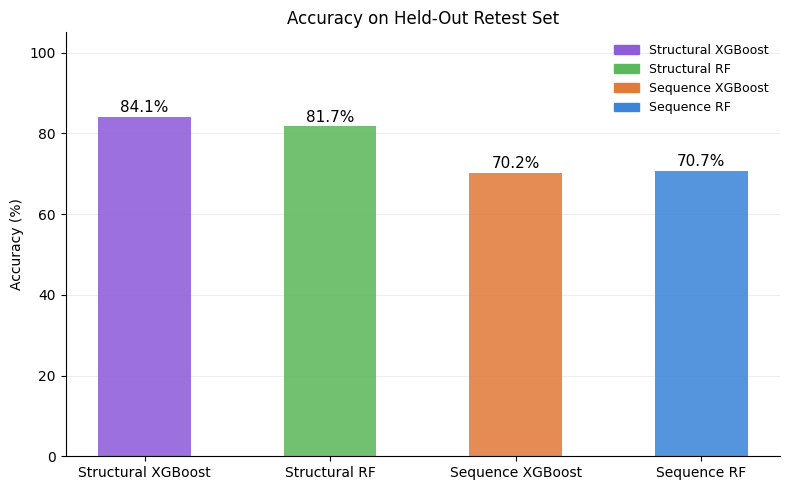

In [6]:
from matplotlib.patches import Patch

names  = list(accuracies.keys())
vals   = list(accuracies.values())
colors = [COLORS[n] for n in names]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(names, vals, color=colors, width=0.5, alpha=0.87)

for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11)

ax.set_ylim(0, 105)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy on Held-Out Retest Set')
ax.grid(True, axis='y', color='#eeeeee', linewidth=0.8)
ax.set_axisbelow(True)
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)

handles = [Patch(color=COLORS[n], label=n) for n in names]
ax.legend(handles=handles, frameon=False, fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()